# Task 2 - Classification
For this task you are given a dataset that contains medical information about 768 patients and tracks the outcome whether a patient has diabetes or not. You are tasked with training a classification model (logistic regression) that can determine whether a patient has diabetes or not using the given data. 

Given:
- Medical info about 768 patients and tracks whether patient has diabetes or not

Action:
- Classify whethere a patient has diabetes

Approach:
-  Logisitic Regression

Goal:
- Patient has diabetes or not 

Complete the following tasks for grading - 
- **(3 points)** Read the dataset into a pandas dataframe and display summary statistic

- **(10 points)** Split the dataset into training (first 514 rows) and testing (last 254 rows) data
- **(5 points)** Fit a logistic regression model on the training data 
- **(5 points)** Predict the outcome (whether a patient has diabetes or not) on the testing data
- **(3 points)** Display the confusion matrix
- **(20 points)** Compute the accuracy, precision, recall and F1 score of the predictions made
- **(4 points)** Plot the ROC curve
---

In [54]:
# Import python packages as needed. Add your import statements in this block if you need more packages
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


**Read the dataset into a pandas dataframe**

In [55]:
# Read regression dataset
data_df = pd.read_csv('../data/classification_data.csv')

# Display summary statistics for the read dataset
data_df.describe()
data_df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

**Split the dataset into training and testing sets**

Use the first 514 rows as training data and the last 254 rows as testing data. Remember that when you are creating a testing dataset, you must separate the features from the target in the data i.e. separate the OutCome target variable (y) from the other features (X).

In [56]:
# Add code here (you may add more cells as you need)

#features(X) and target(Y)

from sklearn.model_selection import train_test_split
#split the first 514 rows as training 
trainX_df = data_df.iloc[:514][['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'Insulin','BMI','DiabetesPedigreeFunction', 'Age']]
trainY_df = data_df.iloc[:514]['Outcome']

#last 254 rows as testing
testX_df = data_df.iloc[514:768][['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'Insulin','BMI','DiabetesPedigreeFunction', 'Age']]
testY_df = data_df.iloc[514:768]['Outcome']

print(trainX_df.head(),trainY_df.head())
print(testX_df.head(), testY_df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33   0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
514            3       99             54             19       86  25.6   
515            3      163             70             18      105  31.6   
516            9      145             88             34      165  30.3  

**Fit a logistic regression model on the training data**

Use the Logistic Regression model from the sklearn package in Python. Alternatively, you could use any other Logistic Regression module.

In [57]:
# Add code here (you may add more cells as you need)
from sklearn.linear_model import LogisticRegression
#empty model
model = LogisticRegression(max_iter=1000)

#use x and y to find line of best fit
model.fit(trainX_df, trainY_df)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Use the trained logistic regression model to predict on the testing data**

In [58]:
# Add code here (you may add more cells as you need)
predictions = model.predict(testX_df)
#probbility of being diabetic

## probability >= 0.5 predict 1 (diabetic)
## probability < 0.5 predict 0 (not diabetic)

print(predictions[:5])
print(testY_df[:5])

[0 1 1 1 0]
514    0
515    1
516    1
517    0
518    0
Name: Outcome, dtype: int64


**Display the confusion matrix**

In [59]:
# Add code here (you may add more cells as you need)
cm =   confusion_matrix(testY_df,predictions)
print("Confusion Matrix:")
print(cm)

#[tn, fp]
#[fn, tp]

#tn: true negative
#fp: false positive
#fn: false negative
#tp: true positive
len(predictions)

Confusion Matrix:
[[157  14]
 [ 34  49]]


254

**Compute the accuracy, precision, recall and F1-score on the testing data**

In [60]:
# Add code here (you may add more cells as you need)

report = classification_report(testY_df, predictions)
print("Classification Report:") 
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       171
           1       0.78      0.59      0.67        83

    accuracy                           0.81       254
   macro avg       0.80      0.75      0.77       254
weighted avg       0.81      0.81      0.80       254



**Plot the ROC curve**

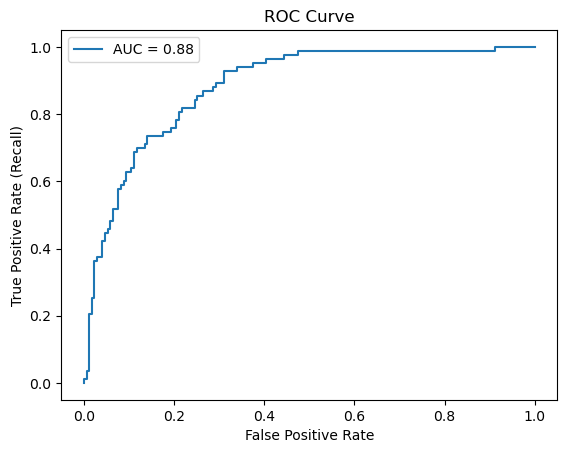

In [ ]:
# Add code here (you may add more cells as you need)

# Probability of being diabetic
y_prob = model.predict_proba(testX_df)[:, 1]  
# false positive rate, true positive rate, and thresholds for ROC curve
fpr, tpr, thresholds = metrics.roc_curve(testY_df, y_prob)
roc_auc = metrics.auc(fpr, tpr)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.show()


ROC curve shows that the model can distinugish between diabetic and non-diabetic patients better than random guessing. The AUC basically measures how well the model separates the two classes across all thresholds. Based on the classification report, the model acheived about 0.81 accuracy, with 0.78 precision, 0.59 recall, and a 0.67 F1 score for the diabetic class.

---